# Week 3: LSTM and GRU Deep Learning Models





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import copy
from pathlib import Path
from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cpu


In [3]:
# Load processed Week 2 data

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (159998, 2)
Validation shape: (20000, 2)
Test shape: (20000, 2)


,clean_text,label
0,have bad conscience my gift for my mom wasn't ...,0
1,some slogging can even take them to pakcricket,0
2,okay this kinda cheered me up lol,1
3,user yea i landed it a while ago like havn't b...,0
4,i have a new blog post for all you victims,1


In [4]:
# Check columns and missing values

print("Train columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in validation:")
print(val_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

Train columns: ['clean_text', 'label']
Validation columns: ['clean_text', 'label']
Test columns: ['clean_text', 'label']

Missing values in train:
clean_text    0
label         0
dtype: int64

Missing values in validation:
clean_text    0
label         0
dtype: int64

Missing values in test:
clean_text    0
label         0
dtype: int64


In [5]:
# Clean possible missing rows and convert data types

train_df = train_df.dropna(subset=["clean_text", "label"]).copy()
val_df = val_df.dropna(subset=["clean_text", "label"]).copy()
test_df = test_df.dropna(subset=["clean_text", "label"]).copy()

train_df["clean_text"] = train_df["clean_text"].astype(str)
val_df["clean_text"] = val_df["clean_text"].astype(str)
test_df["clean_text"] = test_df["clean_text"].astype(str)

train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("After cleaning:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

After cleaning:
Train: (159998, 2)
Validation: (20000, 2)
Test: (20000, 2)


In [6]:
# Check label distribution

print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train label distribution:
label
0    79999
1    79999
Name: count, dtype: int64

Validation label distribution:
label
1    10000
0    10000
Name: count, dtype: int64

Test label distribution:
label
0    10000
1    10000
Name: count, dtype: int64


## 3. Tokenization and Vocabulary



In [7]:
def tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_IDX = 0
UNK_IDX = 1

MAX_VOCAB_SIZE = 50000
MIN_FREQ = 2

# Build vocabulary from training set only
counter = Counter()

for text in train_df["clean_text"].tolist():
    counter.update(tokenize(text))

most_common_words = [
    word
    for word, freq in counter.most_common(MAX_VOCAB_SIZE)
    if freq >= MIN_FREQ
]

itos = [PAD_TOKEN, UNK_TOKEN] + most_common_words
stoi = {word: idx for idx, word in enumerate(itos)}

print("Vocabulary size:", len(itos))
print("\nMost common words:")
print(counter.most_common(20))

Vocabulary size: 29263

Most common words:
[('user', 78777), ('i', 77396), ('to', 56552), ('the', 52046), ('a', 38692), ('my', 32137), ('and', 30539), ('you', 27429), ('it', 23659), ('is', 23258), ('for', 21688), ('in', 21499), ('of', 18518), ('on', 16946), ('me', 16206), ('so', 15300), ('have', 14405), ('that', 14276), ('but', 13507), ("i'm", 13164)]


## 4. Convert Text into Sequences


In [8]:
MAX_LEN = 50

def encode_text(text, stoi, max_len=MAX_LEN):
    tokens = tokenize(text)

    ids = [
        stoi.get(token, UNK_IDX)
        for token in tokens
    ]

    real_length = min(len(ids), max_len)

    if real_length == 0:
        real_length = 1

    ids = ids[:max_len]

    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))

    return ids, real_length


example_text = train_df["clean_text"].iloc[0]
example_encoded, example_length = encode_text(example_text, stoi)

print("Example text:")
print(example_text)

print("\nEncoded sequence:")
print(example_encoded)

print("\nReal length:", example_length)
print("Padded sequence length:", len(example_encoded))

Example text:
have bad conscience my gift for my mom wasn't terrific

Encoded sequence:
[18, 109, 13985, 7, 1517, 12, 7, 319, 498, 7767, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Real length: 10
Padded sequence length: 50


## 5. PyTorch Dataset and DataLoader

PyTorch Dataset stores:

- encoded text sequence;
- real sequence length;
- sentiment label.

DataLoader creates mini-batches for training, validation, and testing.

In [9]:
class TweetDataset(Dataset):
    def __init__(self, dataframe, stoi, max_len):
        self.texts = dataframe["clean_text"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids, length = encode_text(
            self.texts[idx],
            self.stoi,
            self.max_len
        )

        label = self.labels[idx]

        return {
            "input_ids": torch.tensor(text_ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.float)
        }


train_dataset = TweetDataset(train_df, stoi, MAX_LEN)
val_dataset = TweetDataset(val_df, stoi, MAX_LEN)
test_dataset = TweetDataset(test_df, stoi, MAX_LEN)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 159998
Validation dataset size: 20000
Test dataset size: 20000


In [10]:
# Create DataLoaders

BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

batch = next(iter(train_loader))

print("Batch input shape:", batch["input_ids"].shape)
print("Batch length shape:", batch["length"].shape)
print("Batch label shape:", batch["label"].shape)

Batch input shape: torch.Size([256, 50])
Batch length shape: torch.Size([256])
Batch label shape: torch.Size([256])


In [11]:
# Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## 7. Recurrent Neural Network Model

This class can create either an LSTM or GRU model.

Both models include:

- Embedding layer;
- LSTM or GRU layer;
- Dropout layer;
- Fully connected output layer.



In [12]:
class SentimentRNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        output_dim=1,
        num_layers=1,
        dropout=0.4,
        model_type="lstm",
        bidirectional=True
    ):
        super(SentimentRNN, self).__init__()

        self.model_type = model_type.lower()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        if self.model_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=bidirectional
            )
        elif self.model_type == "gru":
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("model_type must be 'lstm' or 'gru'")

        direction_factor = 2 if bidirectional else 1

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * direction_factor, output_dim)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        if self.model_type == "lstm":
            packed_output, (hidden, cell) = self.rnn(packed_embedded)
        else:
            packed_output, hidden = self.rnn(packed_embedded)

        if self.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            final_hidden = torch.cat(
                (forward_hidden, backward_hidden),
                dim=1
            )
        else:
            final_hidden = hidden[-1]

        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)

        return logits.squeeze(1)

## 8. Training and Evaluation Functions

The training function updates model weights.

The evaluation function calculates:

- loss;
- accuracy;
- precision;
- recall;
- F1-score;
- labels;
- predictions;
- probabilities.

A validation threshold is also selected to improve F1-score.

In [13]:
# Training function

def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)

    return avg_loss


# Evaluation function

def evaluate_model(model, data_loader, criterion, device, threshold=0.5):
    model.eval()

    total_loss = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_preds,
        "probabilities": all_probs
    }


# Find best threshold using validation probabilities

def find_best_threshold(labels, probabilities):
    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.30, 0.71, 0.01):
        preds = (probabilities >= threshold).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1

## 9. General Training Function for LSTM and GRU

This function trains a selected model type.

It saves the best model based on validation F1-score.

In [14]:
# Function to train LSTM or GRU

def train_rnn_model(model_type, train_loader, val_loader, device):
    model = SentimentRNN(
        vocab_size=len(itos),
        embedding_dim=128,
        hidden_dim=128,
        output_dim=1,
        num_layers=1,
        dropout=0.4,
        model_type=model_type,
        bidirectional=True
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    EPOCHS = 6

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": []
    }

    best_val_f1 = 0
    best_model_state = None
    best_threshold = 0.5

    print(f"Training {model_type.upper()} model")
    print(model)

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        val_results_default = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            threshold=0.5
        )

        threshold, threshold_f1 = find_best_threshold(
            val_results_default["labels"],
            val_results_default["probabilities"]
        )

        val_results = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            threshold=threshold
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_results["loss"])
        history["val_accuracy"].append(val_results["accuracy"])
        history["val_f1"].append(val_results["f1"])

        if val_results["f1"] > best_val_f1:
            best_val_f1 = val_results["f1"]
            best_model_state = copy.deepcopy(model.state_dict())
            best_threshold = threshold

        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("Train Loss:", round(train_loss, 4))
        print("Validation Loss:", round(val_results["loss"], 4))
        print("Validation Accuracy:", round(val_results["accuracy"], 4))
        print("Validation F1:", round(val_results["f1"], 4))
        print("Best threshold this epoch:", round(threshold, 2))
        print("-" * 50)

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best validation F1 for {model_type.upper()}:", round(best_val_f1, 4))
    print(f"Best threshold for {model_type.upper()}:", round(best_threshold, 2))

    return model, history, best_threshold

## 10. Train LSTM Model



In [15]:
lstm_model, lstm_history, lstm_threshold = train_rnn_model(
    model_type="lstm",
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

Training LSTM model
SentimentRNN(
  (embedding): Embedding(29263, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Epoch 1/6
Train Loss: 0.5163
Validation Loss: 0.4625
Validation Accuracy: 0.7738
Validation F1: 0.7903
Best threshold this epoch: 0.41
--------------------------------------------------
Epoch 2/6
Train Loss: 0.4252
Validation Loss: 0.4382
Validation Accuracy: 0.7862
Validation F1: 0.8005
Best threshold this epoch: 0.34
--------------------------------------------------
Epoch 3/6
Train Loss: 0.3792
Validation Loss: 0.4357
Validation Accuracy: 0.7947
Validation F1: 0.8075
Best threshold this epoch: 0.36
--------------------------------------------------
Epoch 4/6
Train Loss: 0.3367
Validation Loss: 0.4425
Validation Accuracy: 0.7946
Validation F1: 0.8079
Best threshold this epoch: 0.36
--------------------------------------------------
Epoc

## 11. Train GRU Model



In [16]:
gru_model, gru_history, gru_threshold = train_rnn_model(
    model_type="gru",
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

Training GRU model
SentimentRNN(
  (embedding): Embedding(29263, 128, padding_idx=0)
  (rnn): GRU(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Epoch 1/6
Train Loss: 0.5196
Validation Loss: 0.4654
Validation Accuracy: 0.768
Validation F1: 0.7869
Best threshold this epoch: 0.39
--------------------------------------------------
Epoch 2/6
Train Loss: 0.431
Validation Loss: 0.4382
Validation Accuracy: 0.7894
Validation F1: 0.8002
Best threshold this epoch: 0.41
--------------------------------------------------
Epoch 3/6
Train Loss: 0.3875
Validation Loss: 0.4329
Validation Accuracy: 0.7929
Validation F1: 0.8048
Best threshold this epoch: 0.36
--------------------------------------------------
Epoch 4/6
Train Loss: 0.3479
Validation Loss: 0.4388
Validation Accuracy: 0.7935
Validation F1: 0.8072
Best threshold this epoch: 0.37
--------------------------------------------------
Epoch 5/

## 12. Training Plots

The plots show training and validation loss for both deep learning models.

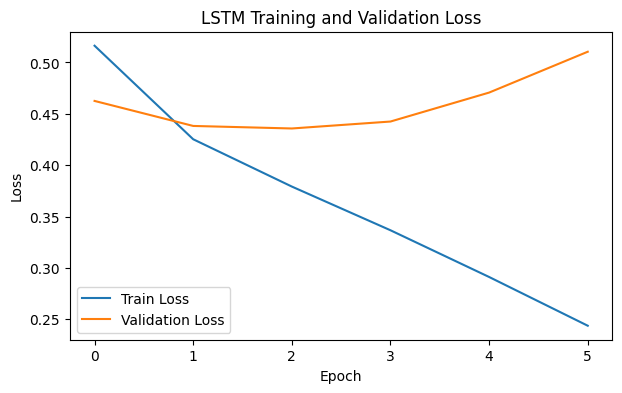

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(lstm_history["train_loss"], label="Train Loss")
plt.plot(lstm_history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

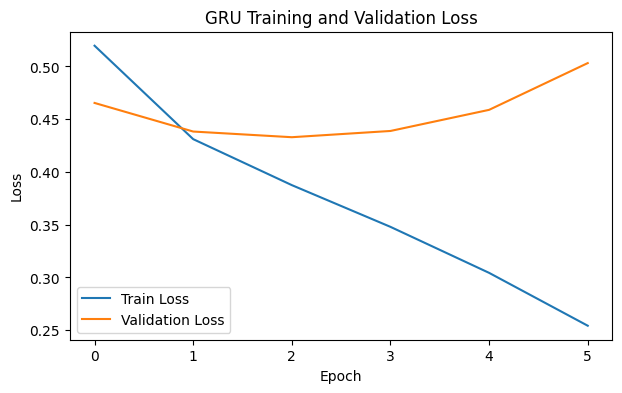

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(gru_history["train_loss"], label="Train Loss")
plt.plot(gru_history["val_loss"], label="Validation Loss")
plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

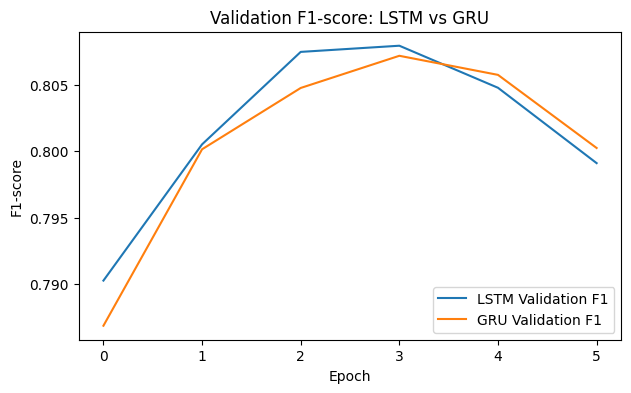

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(lstm_history["val_f1"], label="LSTM Validation F1")
plt.plot(gru_history["val_f1"], label="GRU Validation F1")
plt.title("Validation F1-score: LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.show()

## 13. Test Evaluation

Both LSTM and GRU are evaluated on the same test set.

The test set was not used during training.

In [21]:
criterion = nn.BCEWithLogitsLoss()

lstm_test_results = evaluate_model(
    lstm_model,
    test_loader,
    criterion,
    device,
    threshold=lstm_threshold
)

gru_test_results = evaluate_model(
    gru_model,
    test_loader,
    criterion,
    device,
    threshold=gru_threshold
)

print("LSTM Test Results")
print("-----------------")
print("Accuracy:", round(lstm_test_results["accuracy"], 4))
print("Precision:", round(lstm_test_results["precision"], 4))
print("Recall:", round(lstm_test_results["recall"], 4))
print("F1-score:", round(lstm_test_results["f1"], 4))
print("Threshold:", round(lstm_threshold, 2))

print("\nGRU Test Results")
print("----------------")
print("Accuracy:", round(gru_test_results["accuracy"], 4))
print("Precision:", round(gru_test_results["precision"], 4))
print("Recall:", round(gru_test_results["recall"], 4))
print("F1-score:", round(gru_test_results["f1"], 4))
print("Threshold:", round(gru_threshold, 2))

LSTM Test Results
-----------------
Accuracy: 0.7902
Precision: 0.7539
Recall: 0.8616
F1-score: 0.8042
Threshold: 0.36

GRU Test Results
----------------
Accuracy: 0.7931
Precision: 0.7569
Recall: 0.8635
F1-score: 0.8067
Threshold: 0.37


In [22]:
print("LSTM Classification Report:")
print(
    classification_report(
        lstm_test_results["labels"],
        lstm_test_results["predictions"],
        target_names=["negative", "positive"],
        zero_division=0
    )
)

LSTM Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.72      0.77     10000
    positive       0.75      0.86      0.80     10000

    accuracy                           0.79     20000
   macro avg       0.80      0.79      0.79     20000
weighted avg       0.80      0.79      0.79     20000



In [23]:
print("GRU Classification Report:")
print(
    classification_report(
        gru_test_results["labels"],
        gru_test_results["predictions"],
        target_names=["negative", "positive"],
        zero_division=0
    )
)

GRU Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.72      0.78     10000
    positive       0.76      0.86      0.81     10000

    accuracy                           0.79     20000
   macro avg       0.80      0.79      0.79     20000
weighted avg       0.80      0.79      0.79     20000



## 14. Confusion Matrices

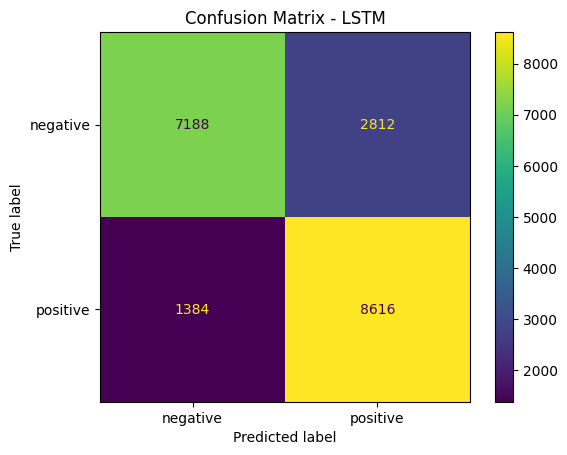

In [24]:
cm_lstm = confusion_matrix(
    lstm_test_results["labels"],
    lstm_test_results["predictions"]
)

disp_lstm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["negative", "positive"]
)

disp_lstm.plot(values_format="d")
plt.title("Confusion Matrix - LSTM")
plt.show()

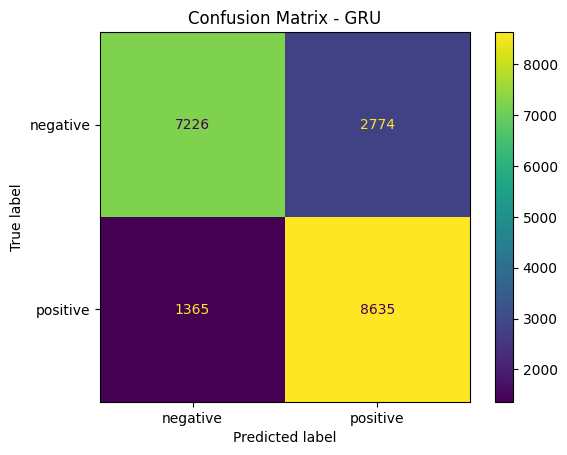

In [25]:
cm_gru = confusion_matrix(
    gru_test_results["labels"],
    gru_test_results["predictions"]
)

disp_gru = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["negative", "positive"]
)

disp_gru.plot(values_format="d")
plt.title("Confusion Matrix - GRU")
plt.show()

## 15. Compare Baseline, LSTM, and GRU



In [27]:
baseline_results = pd.read_csv(baseline_path)

baseline_row = {
    "Model": "Logistic Regression Baseline",
    "Accuracy": baseline_results.loc[0, "test_accuracy"],
    "Precision": baseline_results.loc[0, "test_precision"],
    "Recall": baseline_results.loc[0, "test_recall"],
    "F1-score": baseline_results.loc[0, "test_f1"]
}

lstm_row = {
    "Model": "LSTM",
    "Accuracy": lstm_test_results["accuracy"],
    "Precision": lstm_test_results["precision"],
    "Recall": lstm_test_results["recall"],
    "F1-score": lstm_test_results["f1"]
}

gru_row = {
    "Model": "GRU",
    "Accuracy": gru_test_results["accuracy"],
    "Precision": gru_test_results["precision"],
    "Recall": gru_test_results["recall"],
    "F1-score": gru_test_results["f1"]
}

comparison_results = pd.DataFrame([
    baseline_row,
    lstm_row,
    gru_row
])

comparison_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression Baseline,0.79965,0.794786,0.8079,0.801289
1,LSTM,0.79020,0.753938,0.8616,0.804181
2,GRU,0.79305,0.756859,0.8635,0.806670


In [29]:
best_model_row = comparison_results.loc[
    comparison_results["F1-score"].idxmax()
]

best_model_name = best_model_row["Model"]
best_f1 = best_model_row["F1-score"]

print("Best model based on F1-score:")
print(best_model_name)
print("Best F1-score:", round(best_f1, 4))

Best model based on F1-score:
GRU
Best F1-score: 0.8067


## 16. Error Analysis

This section shows several examples where LSTM and GRU made mistakes.


In [31]:
error_df = pd.DataFrame({
    "text": test_df["clean_text"].values,
    "true_label": lstm_test_results["labels"],
    "lstm_prediction": lstm_test_results["predictions"],
    "gru_prediction": gru_test_results["predictions"],
    "lstm_positive_probability": lstm_test_results["probabilities"],
    "gru_positive_probability": gru_test_results["probabilities"]
})

error_df["true_sentiment"] = error_df["true_label"].map({
    0: "negative",
    1: "positive"
})

error_df["lstm_sentiment"] = error_df["lstm_prediction"].map({
    0: "negative",
    1: "positive"
})

error_df["gru_sentiment"] = error_df["gru_prediction"].map({
    0: "negative",
    1: "positive"
})

error_df.head()

,text,true_label,lstm_prediction,gru_prediction,lstm_positive_probability,gru_positive_probability,true_sentiment,lstm_sentiment,gru_sentiment
0,user i know u don't luv me no more that's y u ...,0,0,0,0.312432,0.180714,negative,negative,negative
1,yesterday i was like yay vacations but no i ha...,0,0,0,0.101532,0.095392,negative,negative,negative
2,user good stuff,1,1,1,0.982886,0.976393,positive,positive,positive
3,enjoying a coffee with my bro at l'esspresso r...,1,1,1,0.996248,0.964153,positive,positive,positive
4,cooking noodles no lunch l,1,1,0,0.742191,0.311317,positive,positive,negative


In [32]:
# LSTM wrong examples

lstm_wrong = error_df[
    error_df["true_label"] != error_df["lstm_prediction"]
]

print("Number of LSTM wrong predictions:", len(lstm_wrong))

lstm_wrong[
    ["text", "true_sentiment", "lstm_sentiment", "lstm_positive_probability"]
].head(10)

Number of LSTM wrong predictions: 4196


,text,true_sentiment,lstm_sentiment,lstm_positive_probability
13,user blackberry bolds and javelins now in stoc...,positive,negative,0.178227
18,user heey girls i miss all you so back the cla...,positive,negative,0.144676
31,user i won't be able to recognize u when i see...,positive,negative,0.291746
45,bored please talk to me,positive,negative,0.118730
47,summer school well my summer was fun while it ...,negative,positive,0.850636
55,gucci mane doin that shit gotta love him just ...,positive,negative,0.313065
56,leavingggg disneyland,negative,positive,0.745516
62,im goin back to my kampung this thursday mcm n...,positive,negative,0.281826
72,didn't see the last minutes of i'm a celebrity...,positive,negative,0.339913
78,in process of selling my orange beaded pickup ...,positive,negative,0.121250


In [33]:
# GRU wrong examples

gru_wrong = error_df[
    error_df["true_label"] != error_df["gru_prediction"]
]

print("Number of GRU wrong predictions:", len(gru_wrong))

gru_wrong[
    ["text", "true_sentiment", "gru_sentiment", "gru_positive_probability"]
].head(10)

Number of GRU wrong predictions: 4139


,text,true_sentiment,gru_sentiment,gru_positive_probability
4,cooking noodles no lunch l,positive,negative,0.311317
12,user oota love time differences was am when u ...,negative,positive,0.802590
18,user heey girls i miss all you so back the cla...,positive,negative,0.222948
21,user i'm sending u a lot of love no checks up ...,negative,positive,0.747915
31,user i won't be able to recognize u when i see...,positive,negative,0.275063
40,watching raven wanting to give user a hug,negative,positive,0.542235
45,bored please talk to me,positive,negative,0.076032
47,summer school well my summer was fun while it ...,negative,positive,0.977854
50,the trickeries of laser carwashing i don't hav...,negative,positive,0.717113
56,leavingggg disneyland,negative,positive,0.934053


In [34]:
# Correct examples for demonstration

correct_examples = error_df[
    (error_df["true_label"] == error_df["lstm_prediction"]) |
    (error_df["true_label"] == error_df["gru_prediction"])
].copy()

correct_examples[
    [
        "text",
        "true_sentiment",
        "lstm_sentiment",
        "gru_sentiment",
        "lstm_positive_probability",
        "gru_positive_probability"
    ]
].head(10)

,text,true_sentiment,lstm_sentiment,gru_sentiment,lstm_positive_probability,gru_positive_probability
0,user i know u don't luv me no more that's y u ...,negative,negative,negative,0.312432,0.180714
1,yesterday i was like yay vacations but no i ha...,negative,negative,negative,0.101532,0.095392
2,user good stuff,positive,positive,positive,0.982886,0.976393
3,enjoying a coffee with my bro at l'esspresso r...,positive,positive,positive,0.996248,0.964153
4,cooking noodles no lunch l,positive,positive,negative,0.742191,0.311317
5,just realized that i don't have class til tomo...,negative,negative,negative,0.097488,0.058859
6,i'm supposed to be at the cmt awards,negative,negative,negative,0.075490,0.016946
7,user yay i'm hot,positive,positive,positive,0.861313,0.945602
8,hoping user busts a dance move in steps or les...,positive,positive,positive,0.831881,0.684249
9,user congratz hun and all the very best,positive,positive,positive,0.968614,0.890484


## 17. Save Week 3 Results


In [36]:
# Save Week 3 result files directly in Colab current folder

week03_results_path = CURRENT_DIR / "week03_lstm_gru_results.csv"
lstm_model_path = CURRENT_DIR / "week03_lstm_model.pt"
gru_model_path = CURRENT_DIR / "week03_gru_model.pt"
vocab_path = CURRENT_DIR / "week03_vocab.json"
error_analysis_path = CURRENT_DIR / "week03_lstm_gru_error_analysis.csv"

comparison_results.to_csv(week03_results_path, index=False)
error_df.to_csv(error_analysis_path, index=False)

torch.save(lstm_model.state_dict(), lstm_model_path)
torch.save(gru_model.state_dict(), gru_model_path)

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(stoi, f, ensure_ascii=False, indent=2)

print("Saved files:")
print(week03_results_path)
print(lstm_model_path)
print(gru_model_path)
print(vocab_path)
print(error_analysis_path)

Saved files:
/content/week03_lstm_gru_results.csv
/content/week03_lstm_model.pt
/content/week03_gru_model.pt
/content/week03_vocab.json
/content/week03_lstm_gru_error_analysis.csv


In [37]:
from google.colab import files

files.download(str(week03_results_path))
files.download(str(lstm_model_path))
files.download(str(gru_model_path))
files.download(str(vocab_path))
files.download(str(error_analysis_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>